# Свёрточные нейронные сети (CNN)

## Мотивация

В этом ноутбуке мы обсудим устройство CNN на примере задачи распознавания изображений. CNN уже стали де-факто стандартом в этой области

> ### Формат данных

Картинки в большинстве случаев представляют собой упорядоченный набор пикселей, где каждый пиксель — это вектор из трех «каналов»: интенсивность красного, интенсивность зелёного, интенсивность синего.

Каждая интенсивность характеризуется числом от $0$ до $1$, но для привычных нам изображений этот интервал равномерно дискретизирован для экономии памяти, чтобы уместиться в 8 бит (от $0$ до $255$). При этом нулевая интенсивность $(0, 0, 0)$, соответствует чёрному цвету, а максимальная интенсивность ($255$, $255$, $255$) — белому.

![alt](../data/1.svg)

Когда мы наблюдаем изображение на мониторе компьютера, мы видим эти пиксели «уложенными» в строки одинаковой длины (человек не сможет воспринять картинку, вытянутую в один вектор). Длину каждой такой строки называют шириной W картинки, а количество строк — высотой $H$. Резюмирую, мы можем рассматривать картинку, как тензор $HxWx3$, состоящий из чисел `uint8`.

![alt](../data/2.svg)


Существует множество разных форматов хранения картинок: вместо трех интенсивностей мы можем использовать триплет «оттенок, насыщенность, интенсивность», а сами картинки хранить, например, как тензор $CxHxW$.

> ### Недостатки MLP

Наверное, самый простой способ построить нейронную сеть для решения задачи классификации на наших данных — это «развернуть» нашу картинку в вектор, а затем использовать обычную многослойную сеть с кросс-энтропией в качестве лосса.

Однако, такой подход имеет несколько недостатков.

![alt](../data/3.gif)

> #### №1: количество параметров
В прошлом для распознавания изображений использовались традиционные MLP. Однако полносвязность между узлами приводила к проклятию размерности и делала обработку изображений с высоким разрешением вычислительно сложной задачей. Изображение размером $1000×1000$ пикселей с цветовыми каналами RGB имеет $3$ миллиона весовых коэффициентов на каждый полносвязный нейрон, что слишком много для эффективной обработки в больших масштабах.

Например, в [CIFAR-10](https://en.wikipedia.org/wiki/CIFAR-10) изображения имеют размер всего $32 \times 32 \times3 $ ($32$ в ширину, $32$ в высоту, $3$ цветовых канала), поэтому у одного полносвязного нейрона в первом скрытом слое обычной нейронной сети будет $32 \times 32 \times 3 = 3072$ весовых коэффициента. Однако изображение размером $200 \times 200$ приведет к появлению нейронов с $200 \times 200 \times 3 = 120 000$ весовых коэффициентов.


> #### №2: структура данных никак не учитывается

Что здесь имеется в виду под «структурой»? Попробуем объяснить на примере. Для этого рассмотрим картинку щеночка:


![alt](../data/puppy.webp)

Если мы сдвинем картинку на несколько пикселей, то мы все еще будем уверены в том, что это щенок:

![alt](../data/puppy_shifted.webp)

Точно также мы останемся неизменны в своем мнении, если картинку отмасштабировать:

![alt](../data/puppy_scaled.webp)


или повернуть/развернуть:

![alt](../data/puppy_rotated.webp)


![alt](../data/puppy_mirrored.webp)

Получается, что нейронная сеть должна «сама» понять, что ее ответ должен быть инвариантен к описанным преобразованиям. Но, обычно, это достигается за счет увеличения количества нейронов в скрытых слоях (как мы можем помнить из universal approximation theorem), что и так для нас — головная боль из-за первого пункта.

С частью этих проблем нам поможет новый «строительный блок» — `свёртка`. О ней в следующем разделе.

> ## Операция свёртки

Давайте попробуем решить хотя бы проблему инвариантности к сдвигу. Щенок может быть где угодно на картинке, и мы не можем наверняка сказать, в какой части изображения наша модель «лучше всего» научилась видеть щенков. Поэтому для надёжного предсказания будет логично посдвигать картинку на все возможные смещения (пустоты заполним нулями):

![alt](../data/shift.svg)

Затем для каждого смещения мы предскажем вероятность наличия щенка на картинке. Получившиеся предсказания можно уже агрегировать как удобно: среднее, максимум и так далее.

Давайте взглянем на эту операцию под другим углом. Рассмотрим картинку, размером в 3 раза превышающую оригинальную, в центре которой находится наше изображение щеночка:

![alt](../data/puppy_black.webp)

Возьмём окно размером с исходную картинку, и будем его сдвигать на все возможные смещения внутри нового изображения:

![alt](../data/conv.svg)


Легко видеть, что получается то же самое, как если бы мы картинку сдвигали относительно окна.

Представим себе самую простую модель, основанную на данном принципе — что-то вроде ансамбля линейных. Каждую из сдвинутых картинок вытянем в вектор и скалярно умножим на вектор весов (для простоты один и тот же для всех сдвигов) — получим линейный оператор, для которого есть специальное имя — **свёртка**.

Это один из важнейших компонент в свёрточных нейронных сетях. Веса свёртки, упорядоченные в тензор (в нашем случае размерности HxWx3), составляют её **ядро**. Область картинки, которая обрабатывается в текущий момент, обычно называется окном свёртки.

Обратите внимание, что обычно такие свёртки называются двумерными — так как окно свёртки пробегает по двум измерениям картинки (при этом все цветовые каналы участвуют в вычислениях).

Следующая картинка поможет разобраться (внимание: на ней `нет` изображения весов оператора):

![alt](../data/tensor.svg)


Фиолетовым выделено окно, из которого мы достаем пиксели и разворачиваем в вектор $V$. Далее этот вектор умножается на ядро свертки $W_1$ (набор весов для одного признака), и получается число $k_1$ — логит этого признака для данного положения окна. Добавив другие признаки при помощи применения других ядер (вертикальные линии, углы и т.д.), получим матрицу весов $W$ — где каждая строка — это отдельное ядро (flatten). Эту операцию (умножение окна на все ядра) мы повторяем для каждого возможного сдвига окна свёртки. Результаты для каждого ядра собираем в отдельную `feature map`.


![alt](../data/3d.gif)


> ### Немного подробнее про ядро (kernel)

`Ядро` — это маленький набор чисел (маленький тензор) (весов), который ищет один простой признак.
Пример признаков:

* вертикальная линия
* горизонтальная линия
* угол
* пятно
* глаз (на глубоком слое)




![alt](../data/conv.gif)



$$B_1 = \frac{1}{9} 
\begin{pmatrix}
1 & 1 & 1 \\
1 & 1 & 1 \\
1 & 1 & 1
\end{pmatrix}$$

**Геометрический смысл:**  
- Изображение становится размытым (сглаженным).  
- Устраняются мелкие детали и шум.  
- Резкие границы "растекаются".  
- Это низкочастотный фильтр (пропускает плавные изменения, подавляет высокие частоты).

$$B_2 = 
\begin{pmatrix}
-1 & -1 & -1 \\
-1 & 8 & -1 \\
-1 & -1 & -1
\end{pmatrix}$$


**Почему это работает:**  
Сумма всех элементов ядра равна $(-1-1-1) + (-1+8-1) + (-1-1-1) = 0$.  
На однородном участке результат будет $0$.  
Если центральный пиксель сильно отличается от соседей (граница), результат будет большим по модулю.

**Геометрический смысл:**  
Это высокочастотный фильтр (подчёркивает резкие изменения, подавляет гладкие области).  
Результат похож на обводку" контуров объектов.

![alt](../data/filters.webp)



> ### Main Idea!

Представьте, что ваша нейросеть смотрит на картинку через маленькое окошко (например, 3×3 пикселя).

Если окошко маленькое, то сеть видит только крошечный кусочек. Она не может понять, что на картинке целый щенок, потому что не видит его целиком.

Решение: увеличить область, которую видит сеть (`receptive field`).

![alt](../data/puppy_big.webp)

Как увеличить область "взгляда" сети?

Есть два способа:

0. Всё же использовать MLP.. (**Фу, не очень**)
1. Взять ядро побольше (например, $7×7$ вместо $3×3$)  (**Это вообще, как у всех**)
2. Добавить несколько слоёв свертки друг за другом - это как раз то  (**Это что такое..?**)

![alt](../data/cascade.svg)


Выглядит так, что мы можем применить уже знакомую технику стекинга слоев: пусть на первой стадии мы делаем $C_1$ разных свёрток с фильтрам размером $kxk$. Результаты каждой свёртки можно упорядочить в виде новой «картинки», а из этих «картинок» сложить трёхмерный тензор. Получаем так называемую карту признаков размером $HxWxC_1$.

Применим к ней поэлементно нелинейность и воспользуемся K новыми свёртками для получения предсказаний для каждого пикселя. На таком шаге получается, что наш `receptive field` для финальных нейронов вырос от $kxk$ до $(2k-1)x(2k-1)$ (пояснение на картинке).

Повторяя такую операцию, мы можем добиться, чтобы наши финальные нейроны уже могли «видеть» почти всю нужную информацию для хорошего предикта. Более того, у нас возникает меньшее количество параметров и падает сложность вычислений в сравнении с использованием одной большой полносвязной сети.

Как это работает на пальцах
1. Слой 1
    * Берём ядро 3×3
    * Смотрим на картинку → получаем карту признаков (новую "картинку")
    * Каждый пиксель этой картинки "видит" кусочек исходной картинки 3×3

2. Слой 2
    * Берём новое ядро 3×3
    * Смотрим на карту признаков (а не на исходную картинку)
    * Каждый пиксель на выходе слоя 2 "видит" кусочек карты признаков 3×3
    * Но карта признаков уже "видит" 3×3 исходной картинки → пересекаясь, получаем 5×5

**Результат**: после двух слоёв с ядром 3×3, рецептивное поле = 5×5.



Ещё один способ увеличить `receptive field` — это использовать `dilated convolution`, в которых окно свёртки (то есть те пиксели картинки, на которые умножается ядро) не обязано быть цельным, а может идти с некоторым шагом (вообще говоря, даже разным по осям H и W).

Проиллюстрируем, как будет выглядеть окно для обычной свёртки и для свёртки с шагом `dilation=2`:

![alt](../data/dilation.webp)

> ### Depth, Padding и Stride

Три гиперпараметра определяют размер выходного объема сверточного слоя: Depth, Stride и Padding:

> #### Depth
- это количество ядер (kernels) в свёрточном слое (Convolutional Layer).

Глубина определяет, **сколько нейронов** в слое смотрят на одну и ту же область входного изображения.

- Каждый такой нейрон (точнее, каждое ядро) учится активироваться **для разных признаков**.
- Пример для первого сверточного слоя (работает с сырыми пикселями):
  - Один нейрон (ядро) может искать **вертикальные границы**.
  - Другой — **горизонтальные границы**.
  - Третий — **пятна цвета**.

Если на вход пришёл тензор размера $H \times W \times C_{\text{in}}$, а мы применили $C_{\text{out}}$ ядер, то глубина выхода = $C_{\text{out}}$.


> #### Stride

Шаг определяет, **на сколько пикселей сдвигается фильтр** за один шаг.

- **Stride = 1**: фильтр сдвигается на 1 пиксель.  
  - Рецептивные поля сильно перекрываются.  
  - Выходной объем получается **большим** (почти как вход).

- **Stride = S** (S > 1): фильтр сдвигается на S пикселей.  
  - Перекрытие меньше.  
  - Пространственные размеры выхода **уменьшаются**.

> #### Padding 

Иногда удобно **добавить нули** (или другие значения) по краям входного объема.  Это и есть **padding**.

- Позволяет **контролировать пространственный размер** выхода.
- Помогает **сохранить размер** картинки на выходе (такое часто называют **"same" padding**).

![alt](../data/padding_stides.gif)

> #### Полный размер выхода
Если на входе:
- высота $H$,
- ширина $W$,
- глубина $C_{\text{in}}$,
- количество ядер $C_{\text{out}}$,
- размер ядра $K$,
- шаг $S$,
- padding $P$,

то выходной тензор будет иметь размер:

$$
H_{\text{out}} = \frac{H - K + 2P}{S} + 1
$$
$$
W_{\text{out}} = \frac{W - K + 2P}{S} + 1
$$
$$
C_{\text{out}} = \text{количество ядер}
$$

Итоговый объем: $\boxed{H_{\text{out}} \times W_{\text{out}} \times C_{\text{out}}}$

Подробнее про гиперпараметры CNN можно почитать [тут](https://en.wikipedia.org/wiki/Convolutional_neural_network#Hyperparameters)

Надеюсь, что всё пока что понятно

![alt](../data/mell.gif)

Бахнем ещё тогда формально определение свёртки:

Пусть $X$ — входной тензор, $K$ — ядро, $S$ — шаг, $P$ — дополнение нулями.

Результат свёртки $Y$ (карта признаков) в позиции $(i, j)$:

$$
Y[i, j] = \sum_{c=1}^{C} \sum_{u=1}^{k_h} \sum_{v=1}^{k_w} 
X\bigl[i\cdot S + u - P,\; j\cdot S + v - P,\; c\bigr] \cdot K[u, v, c]
$$

где:

- $C$ — глубина входного тензора,
- $k_h \times k_w$ — размер ядра,
- $S$ — шаг (stride),
- $P$ — дополнение (padding).


### Обозначение

В литературе по глубокому обучению операцию свёртки часто записывают кратко:

$$
Y = X * K
$$

где $*$ означает **скользящее скалярное произведение** окна $X$ и ядра $K$.

## Архитектура CNN

Теперь рассмотрим какие ещё слои (layers) встречаются в CNN помимо слоя свёртки (Conv layer)

> ### Pooling layer
Еще одна важная концепция сверточных нейронных сетей — это пулинг (pooling), который используется как нелинейный способ понижающего дискретизации. Пулинг обеспечивает понижение размерности (downsampling), поскольку уменьшает пространственные размеры (высоту и ширину) входных карт признаков (feature maps), сохраняя при этом наиболее важную информацию. Существует несколько нелинейных функций для реализации пулинга, среди которых наиболее распространены `maxpiooling` и `avgpooling`. Пулинг объединяет информацию из небольших областей входных данных, создавая разделы входной карты признаков, обычно с использованием окна фиксированного размера (например, 2x2) и шага (часто 2), чтобы перемещать окно по входным данным.

![alt](../data/Convolutional_neural_network,_maxpooling.png)

Интуитивно понятно, что точное расположение объекта не так важно, как его примерное расположение относительно других объектов. На этом принципе основано использование пулинга в свёрточных нейронных сетях. Слой пулинга служит для постепенного уменьшения пространственного размера представления, сокращения количества параметров, объёма памяти и объёма вычислений в сети, а значит, и для контроля переобучения. Это называется понижающей дискретизацией (downsampling). В архитектуре сверточной нейронной сети между последовательными сверточными слоями обычно периодически вставляют слой пулинга (за каждым из которых обычно следует функция активации, например слой ReLU)

> ### ReLU layer

ReLU ([rectified linear unit](https://en.wikipedia.org/wiki/Rectifier_(neural_networks))) - это одна из самых популярных функций активации. Используется в том числе в CNN.

$$ ReLU(x) = max(0, x)$$

ReLU эффективно удаляет отрицательные значения из карты активации, обнуляя их.

ReLU часто предпочитают другим функциям, потому что она позволяет обучать нейронную сеть в несколько раз быстрее без существенного ущерба для обобщения и точности. Она привносит нелинейность в функцию принятия решений и в сеть в целом, не влияя на рецептивные поля свёрточных слоёв.

> ### Flatten
После выделения признаков при помощи стекинга (каскада) свёрток, полученный результат преобразовывается в вектор.

> ### Fully connected layer

После нескольких свёрточных слоёв и слоёв максимального пулинга окончательная классификация выполняется с помощью полносвязных слоёв. Нейроны в полносвязном слое связаны со всеми активациями предыдущего слоя, как в обычных (не свёрточных) искусственных нейронных сетях. Таким образом, их активации можно вычислить с помощью аффинного преобразования, с умножением матриц, за которым следует смещение (bias).

> ### Loss layer

«Слой потерь» (Loss layer) показывает, как критично отклонение между прогнозируемым результатом работы сети и истинными метками данных (при обучении с учителем). В зависимости от конкретной задачи можно использовать различные функции потерь.

К примеру, лосс `Softmax` используется для прогнозирования принадлежности к одному из $K$ взаимоисключающих классов.

![alt](../data/convolution-01.webp)

## Небольшой пример на практике

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
from tqdm.notebook import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

GPU: NVIDIA GeForce RTX 2060


In [ ]:
# CIFAR-10: 50k тренировочных, 10k тестовых, изображения 32x32x3 (RGB)

transform = transforms.Compose([
    transforms.ToTensor(),           # из PIL в тензор (0..1)
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  # нормализация в (-1..1)
])

# Загрузка датасетов
train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

# Создание DataLoader'ов
batch_size = 128  # У RTX 2060 6 ГБ VRAM.
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

# Имена классов CIFAR-10
classes = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

100%|██████████| 170M/170M [01:21<00:00, 2.10MB/s] 
c:\Users\79222\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


In [3]:
class CNN(nn.Module):
    def __init__(self, num_classes=10):
        super(CNN, self).__init__()

        self.conv_layers = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),  # 32x32x32
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 16x16x32

            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1), # 16x16x64
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 8x8x64

            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1), # 8x8x128
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 4x4x128
        )

        self.fc_layers = nn.Sequential(
            nn.Flatten(),  # 4*4*128 = 2048
            nn.Linear(4*4*128, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x

In [4]:
class MLP(nn.Module):
    def __init__(self, num_classes=10):
        super(MLP, self).__init__()

        self.flatten = nn.Flatten()

        self.fc_layers = nn.Sequential(
            nn.Linear(32*32*3, 1024),  # 3072 -> 1024
            nn.ReLU(),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.flatten(x)
        x = self.fc_layers(x)
        return x

In [12]:
def train_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(train_loader, desc='Training', leave=False, position=0):
        images, labels = images.to(device), labels.to(device)

        # Обнуляем градиенты
        optimizer.zero_grad()

        # Прямой проход
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Обратный проход
        loss.backward()
        optimizer.step()

        # Статистика
        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = 100.0 * correct / total
    return epoch_loss, epoch_acc

In [13]:
def evaluate(model, test_loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc='Testing', leave=False, position=0):
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = 100.0 * correct / total
    return epoch_loss, epoch_acc

In [14]:
def train_model(model, model_name, train_loader, test_loader, epochs=10, lr=0.001):

    def count_parameters(model):
        return sum(p.numel() for p in model.parameters() if p.requires_grad)

    print(f"\n{'='*50}")
    print(f"Обучение модели: {model_name}")
    print(f"Количество параметров: {count_parameters(model):,}")
    print(f"{'='*50}")


    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    train_losses = []
    test_losses = []
    train_accs = []
    test_accs = []

    for epoch in range(epochs):
        print(f"\nЭпоха {epoch+1}/{epochs}")

        # Обучение
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        train_losses.append(train_loss)
        train_accs.append(train_acc)

        # Тестирование
        test_loss, test_acc = evaluate(model, test_loader, criterion, device)
        test_losses.append(test_loss)
        test_accs.append(test_acc)

        print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
        print(f"  Test  Loss: {test_loss:.4f} | Test  Acc: {test_acc:.2f}%")

    return {
        'model': model,
        'name': model_name,
        'train_losses': train_losses,
        'test_losses': test_losses,
        'train_accs': train_accs,
        'test_accs': test_accs,
        'params': count_parameters(model)
    }

In [15]:
epochs = 7  # для быстрой демонстрации (можно увеличить до 20-30)

# Создаём модели
cnn_model = CNN(num_classes=10)
mlp_model = MLP(num_classes=10)

# Обучаем CNN
cnn_results = train_model(cnn_model, "CNN (Свёрточная сеть)",
                          train_loader, test_loader, epochs=epochs)

# Обучаем MLP
mlp_results = train_model(mlp_model, "MLP (Полносвязная сеть)",
                          train_loader, test_loader, epochs=epochs)


Обучение модели: CNN (Свёрточная сеть)
Количество параметров: 620,362

Эпоха 1/7


  Train Loss: 1.3807 | Train Acc: 50.05%
  Test  Loss: 1.1928 | Test  Acc: 58.21%

Эпоха 2/7


  Train Loss: 0.9467 | Train Acc: 66.43%
  Test  Loss: 0.8842 | Test  Acc: 68.91%

Эпоха 3/7


  Train Loss: 0.7549 | Train Acc: 73.59%
  Test  Loss: 0.7942 | Test  Acc: 71.96%

Эпоха 4/7


  Train Loss: 0.6186 | Train Acc: 78.40%
  Test  Loss: 0.7694 | Test  Acc: 73.79%

Эпоха 5/7


...

  Train Loss: 1.3279 | Train Acc: 53.02%
  Test  Loss: 1.4039 | Test  Acc: 51.41%

Эпоха 4/7


  Train Loss: 1.2315 | Train Acc: 56.40%
  Test  Loss: 1.3811 | Test  Acc: 52.58%

Эпоха 5/7


  Train Loss: 1.1484 | Train Acc: 59.24%
  Test  Loss: 1.3820 | Test  Acc: 53.59%

Эпоха 6/7


  Train Loss: 1.0634 | Train Acc: 62.08%
  Test  Loss: 1.4004 | Test  Acc: 53.66%

Эпоха 7/7


  Train Loss: 0.9832 | Train Acc: 64.88%
  Test  Loss: 1.3995 | Test  Acc: 54.08%


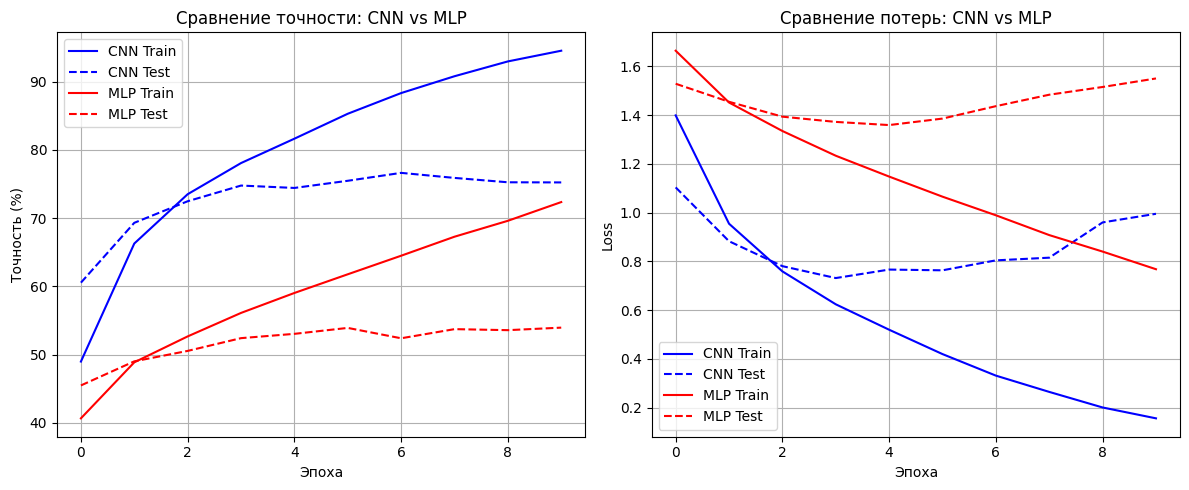

In [ ]:
# Визуализация сравнения результатов
plt.figure(figsize=(12, 5))

# График точности
plt.subplot(1, 2, 1)
plt.plot(cnn_results['train_accs'], 'b-', label='CNN Train')
plt.plot(cnn_results['test_accs'], 'b--', label='CNN Test')
plt.plot(mlp_results['train_accs'], 'r-', label='MLP Train')
plt.plot(mlp_results['test_accs'], 'r--', label='MLP Test')
plt.xlabel('Эпоха')
plt.ylabel('Точность (%)')
plt.title('Сравнение точности: CNN vs MLP')
plt.legend()
plt.grid(True)

# График потерь
plt.subplot(1, 2, 2)
plt.plot(cnn_results['train_losses'], 'b-', label='CNN Train')
plt.plot(cnn_results['test_losses'], 'b--', label='CNN Test')
plt.plot(mlp_results['train_losses'], 'r-', label='MLP Train')
plt.plot(mlp_results['test_losses'], 'r--', label='MLP Test')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.title('Сравнение потерь: CNN vs MLP')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

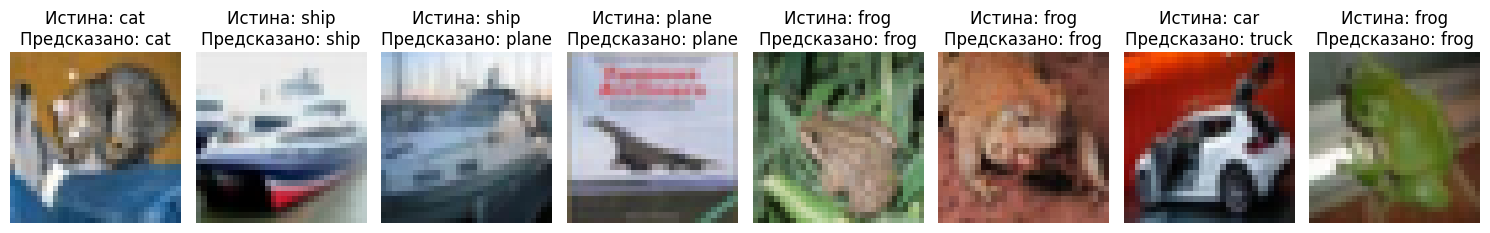

In [9]:
def show_predictions(model, test_loader, device, num_images=5):
    model.eval()
    data_iter = iter(test_loader)
    images, labels = next(data_iter)
    images, labels = images[:num_images].to(device), labels[:num_images]

    with torch.no_grad():
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

    # Денормализация для отображения
    images = images.cpu() * 0.5 + 0.5  # возвращаем из (-1..1) в (0..1)

    fig, axes = plt.subplots(1, num_images, figsize=(15, 3))
    for i in range(num_images):
        ax = axes[i]
        img = images[i].permute(1, 2, 0).numpy()
        ax.imshow(img)
        ax.set_title(f"Истина: {classes[labels[i]]}\nПредсказано: {classes[predicted[i]]}")
        ax.axis('off')
    plt.tight_layout()
    plt.show()

# Показываем предсказания обученной CNN
show_predictions(cnn_results['model'], test_loader, device, num_images=8)